# PyTorch Time Series Model Training and Evaluation

This notebook is converted from `main.py`. Edit the parameters in the next cell to control the workflow.


//LSTM,CNN,BiLSTM,RNN,AttentionLSTM,AR,


In [1]:
# --- Parameters (edit these as needed) ---
window_size = 48
label_width = 1
training_stride = 8
validation_stride = 8
offset = 48
epochs = 30    
patience = 10
batch_size = 32
features = 'SWC_20,T_20,Ppt,Wx,Wy,Srad,DayCos,DaySin,MonthCos,MonthSin'
predict_features = 'SWC_20'
model_names='baseline,ilstm_soil'
# model_names = 'Baseline'

In [2]:
import os
import copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Assuming 'models.py' contains the fully converted PyTorch models.
import models as model_module

%matplotlib inline


In [3]:
# --- Helper for Early Stopping ---
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model_state = None
        self.best_loss = float('inf')
        self.counter = 0

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            if self.restore_best_weights:
                self.best_model_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1

        if self.counter >= self.patience:
            print("--- Early stopping triggered ---")
            if self.restore_best_weights and self.best_model_state is not None:
                print("Restoring best model weights.")
                model.load_state_dict(self.best_model_state)
            return True
        return False

In [4]:
# --- Comprehensive Evaluation Function ---
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        batch_iter = tqdm(dataloader, desc=f"Val Batches", leave=False)
        for X_batch, y_batch in batch_iter:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if y_pred.shape != y_batch.shape:
                y_pred = y_pred.view_as(y_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            all_preds.append(y_pred.cpu())
            all_targets.append(y_batch.cpu())
    all_preds = torch.cat(all_preds, dim=0).squeeze()
    all_targets = torch.cat(all_targets, dim=0).squeeze()
    epsilon = 1e-8
    num_samples = len(all_targets)
    mse = total_loss / num_samples
    mae = torch.mean(torch.abs(all_targets - all_preds)).item()
    print(torch.abs((all_targets - all_preds) / (all_targets + epsilon)).sum())
    print(torch.abs((all_targets - all_preds)).max())
    mape = (torch.mean(torch.abs((all_targets - all_preds) / (all_targets + epsilon))) * 100)
    smape_numerator = torch.abs(all_preds - all_targets)
    smape_denominator = torch.abs(all_targets) + torch.abs(all_preds) + epsilon
    smape = torch.mean(2 * smape_numerator / smape_denominator) * 100
    rse_numerator = torch.sum((all_preds - all_targets) ** 2)
    rse_denominator = torch.sum((all_targets - torch.mean(all_targets)) ** 2) + epsilon
    rse = (rse_numerator / rse_denominator).item()
    vx = all_targets - torch.mean(all_targets)
    vy = all_preds - torch.mean(all_preds)
    corr = torch.sum(vx * vy) / (torch.sqrt(torch.sum(vx ** 2)) * torch.sqrt(torch.sum(vy ** 2)) + epsilon)
    return {
        'MSE': mse,
        'MAE': mae,
        'MAPE': mape.item(),
        'SMAPE': smape.item(),
        'RSE': rse,
        'CORR': corr.item()
    }

In [5]:
# --- Main Pipeline ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Data Loading and Preparation ---
try:
    from core.data_helpers import read_and_process_csvs, engineer_features, split_and_stack_data, normalize_features, data_to_X_y
    from core.evaluation_helpers import write_loss_history_to_csv, write_model_results_to_csv
except ImportError:
    print("Warning: 'core' module not found. Using placeholder data and dummy output functions.")
    def read_and_process_csvs(): return {f'Station{i+1}': pd.DataFrame(np.random.rand(100, 6), columns=['SWC_20', 'T_20', 'Ppt', 'Tair', 'Wx', 'Wy']) for i in range(6)}
    def engineer_features(dfs): return dfs
    def split_and_stack_data(dfs, test_station_name): return dfs, dfs[test_station_name], dfs[test_station_name]
    def normalize_features(df, features): return df, None
    def data_to_X_y(df, window, offset): return np.random.rand(50, window, len(df.columns)), np.random.rand(50)
    def write_loss_history_to_csv(*args): pass
    def write_model_results_to_csv(station, model_name, ws, offset, perf, features):
        print(f"DUMMY_WRITE: Writing results for {model_name}...")
        print(f"  -> MSE: {perf.get('MSE', 'N/A')}, CORR: {perf.get('CORR', 'N/A')}")

stations = ['Station1', 'Station2', 'Station3', 'Station4', 'Station5', 'Station6']
target_station = stations[-1]
raw_dfs = read_and_process_csvs()
engineered_dfs = engineer_features(raw_dfs)
train_dfs, val_dfs, test_df = split_and_stack_data(engineered_dfs, test_station_name=target_station)
all_features = features.split(',') if features else ['SWC_20', 'T_20', 'Ppt', 'Tair', 'Wx', 'Wy']

Using device: cuda
Reading CSV: Revised_Final_Data/Station1_Revised_Final_Data.csv
Reading CSV: Revised_Final_Data/Station2_Revised_Final_Data.csv
Reading CSV: Revised_Final_Data/Station3_Revised_Final_Data.csv
Reading CSV: Revised_Final_Data/Station4_Revised_Final_Data.csv
Reading CSV: Revised_Final_Data/Station5_Revised_Final_Data.csv
Reading CSV: Revised_Final_Data/Station6_Revised_Final_Data.csv
Engineering features for Station1
Engineering features for Station2


c:\Users\flare\anaconda3\envs\soil_moisture\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Engineering features for Station3
Engineering features for Station4
Engineering features for Station5
Engineering features for Station6
TEST DF: 2020-01-01 00:00:00 to 2020-12-31 23:00:00


In [6]:
def data_to_X_y(data, window_size, offset, label_width, label_columns):
    # Calculate the number of rows for X and y
    rows = len(data) - window_size - (offset - 1) - label_width + 1

    # Now, use sliding_window_view to create the X array
    X = np.lib.stride_tricks.sliding_window_view(data, (window_size, data.shape[1]))[:rows, 0]
    # Then we slice the y array accordingly
    y = np.lib.stride_tricks.sliding_window_view(data[window_size + offset - 1:], (label_width, data.shape[1]))[:, 0, :]
    y = y[:, :, label_columns]
    # y = data[window_size + offset - 1: window_size + offset - 1 + rows, label_column]
    return X, y


In [7]:
# --- Prepare data and convert to PyTorch Tensors ---
predict_features_list = predict_features.split(',')
indices = [all_features.index(f) for f in predict_features_list]
# scaled_val, _ = normalize_features(val_df, all_features)
# X_val, y_val = data_to_X_y(scaled_val, window_size, offset, label_width, indices)

# X_val = X_val[::validation_stride]
# y_val = y_val[::validation_stride]

scaled_test, _ = normalize_features(test_df, all_features)
X_test, y_test = data_to_X_y(scaled_test, window_size, offset, label_width, indices)
train_data_x, train_data_y = [], []
# for train_station in [s for s in stations if s != target_station]:
#     scaled_train, _ = normalize_features(engineered_dfs[train_station], all_features)
#     X_train_part, y_train_part = data_to_X_y(scaled_train, window_size, offset, label_width, indices)
    
#     X_train_part = X_train_part[::training_stride]
#     y_train_part = y_train_part[::training_stride]
    
#     train_data_x.append(X_train_part)
#     train_data_y.append(y_train_part)
for df in train_dfs:
    scaled_train, _ = normalize_features(df, all_features)
    X_train_part, y_train_part = data_to_X_y(scaled_train, window_size, offset, label_width, indices)
    
    X_train_part = X_train_part[::training_stride]
    y_train_part = y_train_part[::training_stride]
    
    train_data_x.append(X_train_part)
    train_data_y.append(y_train_part)
X_train = np.concatenate(train_data_x, axis=0)
y_train = np.concatenate(train_data_y, axis=0)

val_data_x, val_data_y = [], []
for df in val_dfs:
    scaled, _ = normalize_features(df, all_features)
    X_part, y_part = data_to_X_y(scaled, window_size, offset, label_width, indices)
    X_part = X_part[::validation_stride]
    y_part = y_part[::validation_stride]
    val_data_x.append(X_part)
    val_data_y.append(y_part)
X_val = np.concatenate(val_data_x, axis=0)
y_val = np.concatenate(val_data_y, axis=0)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size)
model_dir = "saved_models_pytorch"
os.makedirs(model_dir, exist_ok=True)

In [8]:
import importlib
import models as model_module

importlib.reload(model_module)

# --- Model Selection ---
def normalize_id(name: str) -> str:
    return name.lower().replace("_", "").replace("model", "")


requested_ids = set(normalize_id(n) for n in model_names.split(","))

model_map = {
    "ar": model_module.AR,
    "autoregressive": model_module.AR,
    "lstm": model_module.LSTMModel,
    "bilstm": model_module.BiLSTMModel,
    "rnn": model_module.RNNModel,
    "cnn": model_module.CNNModel,
    "attentionlstm": model_module.AttentionLSTM,
    "attentiononly": model_module.AttentionOnly,
    "transformer": model_module.TransformerModel,
    "multiheadlstm": model_module.MultiHeadLSTM,
    "ilstmsoil": model_module.ILSTM_Soil,
    "baseline": model_module.Baseline,
    "movingaverage": model_module.MovingAverageBaseline,
}
process_queue = {
    name: model_class
    for name, model_class in model_map.items()
    if name in requested_ids
}
print(f"Models to be processed: {list(process_queue.keys())}")

Models to be processed: ['ilstmsoil', 'baseline']


In [9]:
def plot_original_vs_predicted(original, predicted, variable_name="Variable", title="Original vs Predicted"):
    plt.figure(figsize=(10, 5))
    plt.plot(original, label="Original", marker='o', markersize=1)
    plt.plot(predicted, label="Predicted", marker='x', linestyle='--', markersize=1)
    plt.title(title + f" ({variable_name})")
    plt.xlabel("Time Step")
    plt.ylabel(variable_name)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [10]:
def visualize_predictions(model, X_test, y_test, variable_name="Soil Moisture", title="Model Predictions"):
    model.eval()
    # print(X_test.shape, "X_test shape")
    # print(y_test.shape, "y_test shape")
    # print(X_test[:5,:,0], "First 5 samples of X_test")
    # print(y_test[:5], "First 5 samples of y_test")
    with torch.no_grad():
        y_pred = model(X_test).cpu().numpy().flatten()
        # y_pred = np.round(y_pred, 3)
        y_test = y_test.cpu().numpy().flatten()
    plot_original_vs_predicted(y_test, y_pred, variable_name=variable_name, title=title)

In [11]:
%matplotlib inline


===== Processing ILSTMSOIL =====
Training ILSTMSOIL...
Input shape for ILSTM_Soil: T=48, N=10


Epochs (ilstmsoil):   0%|          | 0/30 [00:00<?, ?it/s]

Batches (Epoch 1):   0%|          | 0/683 [00:00<?, ?it/s]

Val Batches:   0%|          | 0/341 [00:00<?, ?it/s]

tensor(71283472.)
tensor(0.6163)


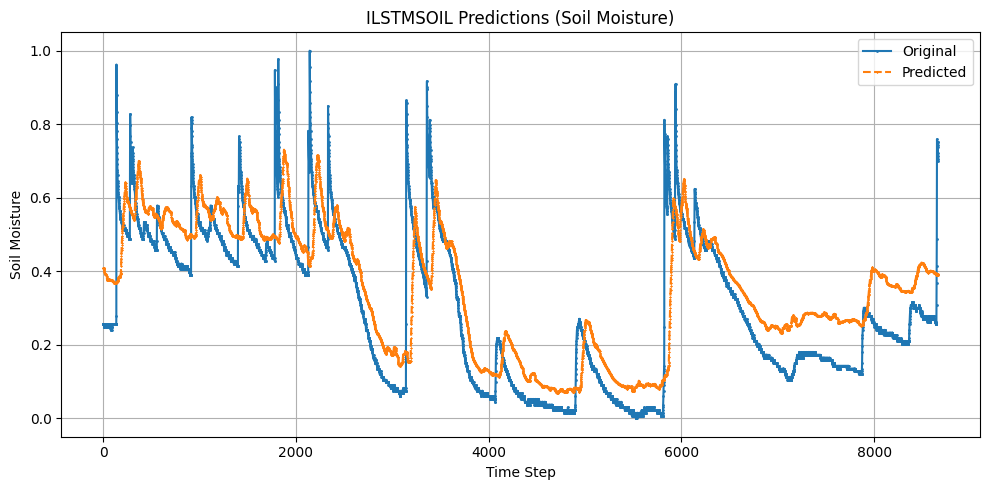

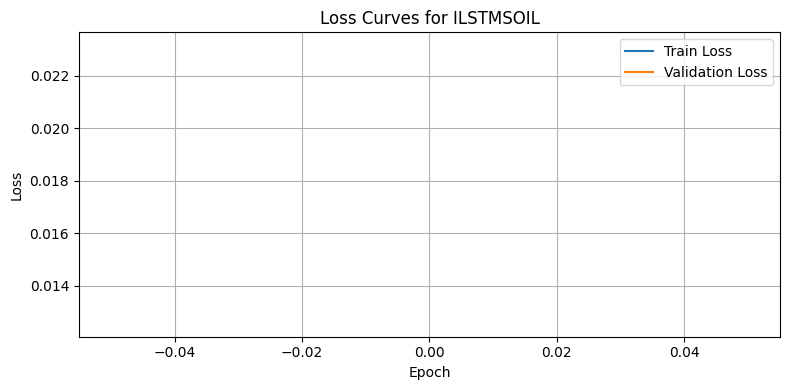

Batches (Epoch 2):   0%|          | 0/683 [00:00<?, ?it/s]

Val Batches:   0%|          | 0/341 [00:00<?, ?it/s]

tensor(44106424.)
tensor(0.6829)


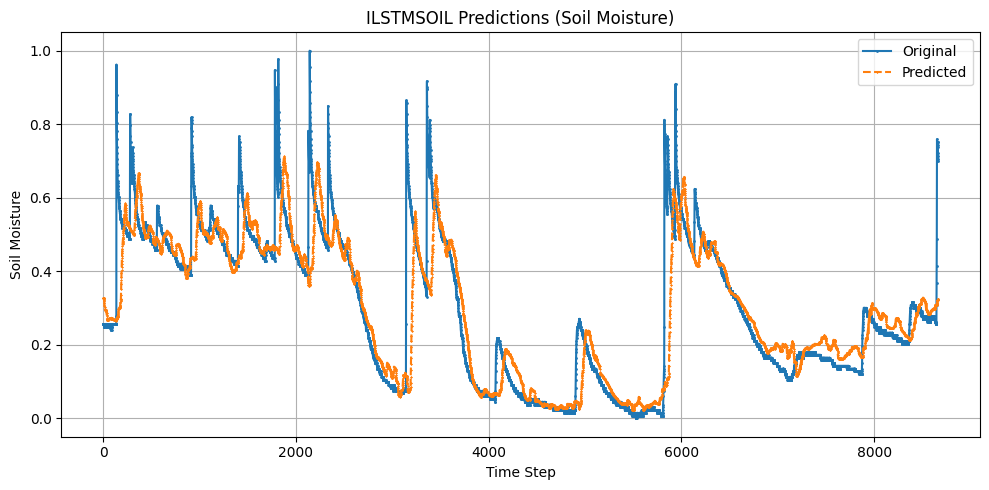

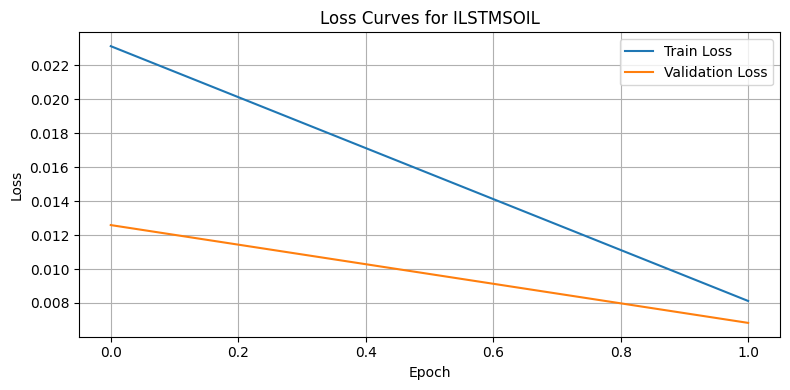

Batches (Epoch 3):   0%|          | 0/683 [00:00<?, ?it/s]

Val Batches:   0%|          | 0/341 [00:00<?, ?it/s]

tensor(49843120.)
tensor(0.6777)


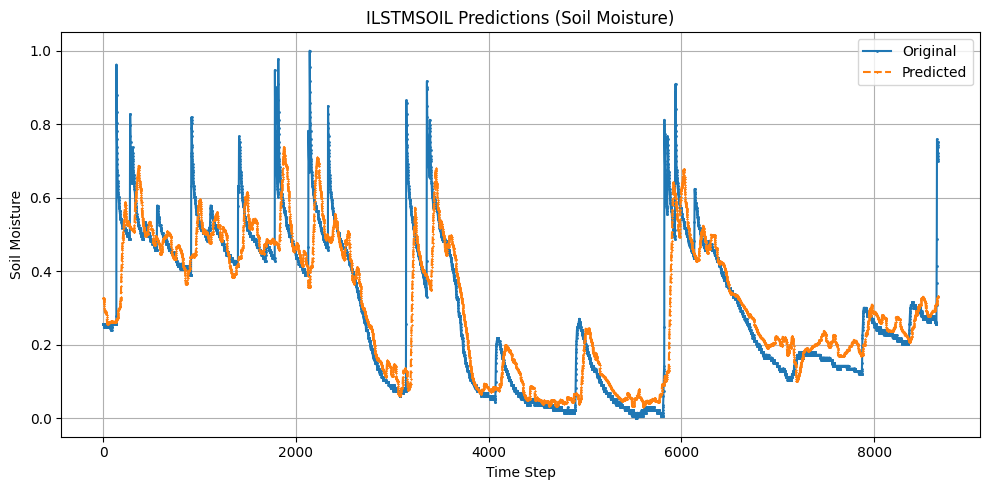

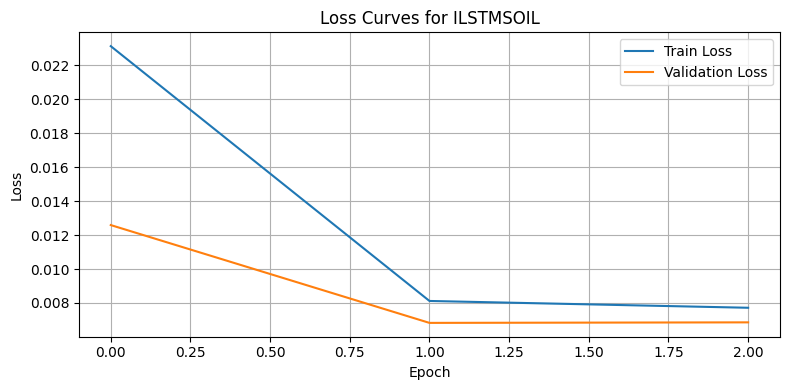

Batches (Epoch 4):   0%|          | 0/683 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
# --- Training and Evaluation Loop ---

for model_name, model_class in process_queue.items():
    feature_str = ""
    print(f"\n===== Processing {model_name.upper()} =====")
    input_dim = X_train_t.shape[2]
    criterion = nn.MSELoss()
    if model_name in ["baseline", "movingaverage"]:
        print(f"Evaluating non-trainable baseline model: {model_name.upper()}")
        model = model_class(label_width).to(device)
        performance = evaluate_model(model, test_loader, criterion, device)
        visualize_predictions(model, X_test_t.to(device), y_test_t.to(device), variable_name="Soil Moisture", title=f"{model_name.upper()} Predictions")
    else:
        print(f"Training {model_name.upper()}...")
        if model_name == "ilstmsoil":
            _, T, N = X_train_t.shape
            print(f"Input shape for ILSTM_Soil: T={T}, N={N}")
            model = model_class(time_steps=T, num_features=N).to(device)
        else:
            model = model_class(input_dim=input_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
        # lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
        early_stopper = EarlyStopping(patience=patience, restore_best_weights=True)
        history = {'loss': [], 'val_loss': []}
        epoch_iter = tqdm(range(epochs), desc=f"Epochs ({model_name})")
        for epoch in epoch_iter:
            model.train()
            epoch_loss = 0
            batch_iter = tqdm(train_loader, desc=f"Batches (Epoch {epoch+1})", leave=False)
            for X_batch, y_batch in batch_iter:
                
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                y_pred = model(X_batch)
                # print(y_pred.shape, "y_pred shape")
                # print(y_batch.squeeze(-1).shape, "y_batch shape")
                loss = criterion(y_pred, y_batch.squeeze(-1))
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * X_batch.size(0)
            val_metrics = evaluate_model(model, val_loader, criterion, device)
            visualize_predictions(model, X_test_t.to(device), y_test_t.to(device), variable_name="Soil Moisture", title=f"{model_name.upper()} Predictions")
            train_loss = epoch_loss / len(train_loader.dataset)
            val_loss = val_metrics['MSE']
            # lr_scheduler.step()
            
            history['loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            epoch_iter.set_postfix({"Train Loss": f"{train_loss:.6f}", "Val Loss": f"{val_loss:.6f}"})
            if early_stopper(val_loss, model):
                break
            
            plt.figure(figsize=(8, 4))
            plt.plot(history['loss'], label='Train Loss')
            plt.plot(history['val_loss'], label='Validation Loss')
            plt.title(f"Loss Curves for {model_name.upper()}")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        print("\nFinal Evaluation on Test Set...")
        performance = evaluate_model(model, test_loader, criterion, device)
        feature_str = '_'.join(all_features)
        main_name = f"model_{model_name}_ws{window_size}_offset{offset}_{feature_str}"
        model_path = os.path.join(model_dir, f"{main_name}.pth")
        torch.save(model.state_dict(), model_path)
        print(f"{model_name.upper()} model saved at {model_path}")
        write_loss_history_to_csv(target_station, model_name, window_size, offset, history, feature_str)
    print(f"\n--- {model_name.upper()} Final Test Metrics ---")
    for key, value in performance.items():
        print(f"{key}: {value:.6f}")
    write_model_results_to_csv(target_station, model_name, window_size, offset, performance, feature_str)
    print("-------------------------------------\n")
print("All runs complete! Results have been saved.")